# Abrir el dataset anemoi de ERA5 Iberia

Dataset generado con `anemoi-datasets create recipes/iberia.yaml data/zarr/iberia-anemoi.zarr` (ver D-014). Aquí se abre con `anemoi.datasets.open_dataset`, que es como lo consume anemoi-training.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from anemoi.datasets import open_dataset

PATH = "../data/zarr/iberia-anemoi.zarr"
ds = open_dataset(PATH)

## Forma, variables y fechas

La forma es `(fechas, variables, ensemble, puntos)`: la rejilla 41×61 se aplana a 2501 puntos.

In [2]:
print("shape:", ds.shape)
print("variables:", ds.variables)
print("fechas:", ds.dates[0], "->", ds.dates[-1], "| frecuencia:", ds.frequency)
print("field_shape:", ds.field_shape, "| resolución:", ds.resolution)

shape: (4383, 10, 1, 2501)
variables: ['10u', '10v', '2t', 'msl', 'sp', 't_500', 't_850', 'tp', 'z_500', 'z_850']
fechas: 2020-01-01T06:00:00 -> 2022-12-31T18:00:00 | frecuencia: 6:00:00
field_shape: (41, 61) | resolución: 0.25


## Subconjunto por fechas y variables

In [3]:
jan21 = open_dataset(PATH, start="2021-01", end="2021-01", select=["2t", "tp"])
print(jan21.shape, jan21.variables, jan21.dates[0], "->", jan21.dates[-1])

(124, 2, 1, 2501) ['2t', 'tp'] 2021-01-01T00:00:00 -> 2021-01-31T18:00:00


## Mapa de `2t`

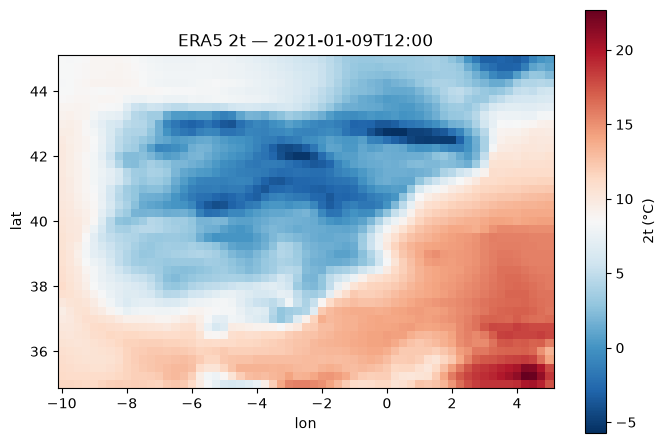

In [4]:
date = np.datetime64("2021-01-09T12:00")  # borrasca Filomena
i = int(np.where(jan21.dates == date)[0][0])
t2m = jan21[i, jan21.name_to_index["2t"], 0, :].reshape(ds.field_shape) - 273.15
lat = jan21.latitudes.reshape(ds.field_shape)
lon = jan21.longitudes.reshape(ds.field_shape)
lon = np.where(lon > 180, lon - 360, lon)

fig, ax = plt.subplots(figsize=(8, 5.5))
m = ax.pcolormesh(lon, lat, t2m, cmap="RdBu_r", shading="nearest")
fig.colorbar(m, ax=ax, label="2t (°C)")
ax.set(title=f"ERA5 2t — {date}", xlabel="lon", ylabel="lat", aspect="equal")
plt.show()